<a href="https://colab.research.google.com/github/ChaitanyaHandore/Abstraction/blob/main/New_thesis_notebook_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Business Understanding

**Project Title:** Automated Crop Disease Classification  
**Problem Statement:**  
I want to build a model that, given an image of a crop leaf, can accurately identify which disease (or healthy status) it shows. This will help farmers rapidly diagnose issues and take timely action.

**Objectives:**  
- Train a computer-vision model to classify leaf images into their correct disease category.  
- Achieve ≥ 85% validation accuracy across all classes.  
- Handle class imbalance so that rare diseases aren’t neglected.


---



# Setup & Imports

I configure CUDA launch blocking for easier debugging, install the core PyTorch, import all the libraries I’ll need, mount Google Drive, and unpack my dataset.

In [ ]:
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [ ]:
!pip install torch torchvision timm --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch.nn as nn
from torchvision import models
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

print("✅ Libraries loaded.")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.8 MB/s eta 0:00:00
✅ Libraries loaded.
Torch: 2.6.0+cu124
CUDA available: True


# Unzip Dataset & Inspect Folder Structure

I unzip `disease_data.zip` from Drive into `/content/data/` , then list out the top-level folders to confirm I have the expected `train/`, `val/`, and `test/` splits, and that each crop directory contains its disease subfolders.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q /content/drive/MyDrive/disease_data.zip -d /content/data/

Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/disease_data.zip -d /content/

In [ ]:
# Verify the top-level folders
!ls /content/disease_data

In [ ]:
# Inspect one split
!ls /content/data/disease_data/train

Cashew_anthracnose	  Cassava_healthy      Maize_streak_virus
Cashew_gumosis		  Cassava_mosaic       Tomato_healthy
Cashew_healthy		  Maize_fall_armyworm  Tomato_leaf_blight
Cashew_leaf_miner	  Maize_grasshoper     Tomato_leaf_curl
Cashew_red_rust		  Maize_healthy        Tomato_septoria_leaf_spot
Cassava_bacterial_blight  Maize_leaf_beetle    Tomato_verticulium_wilt
Cassava_brown_spot	  Maize_leaf_blight
Cassava_green_mite	  Maize_leaf_spot


#Step 2: Data Mining & Exploration


##2.1. Compute Class Distribution

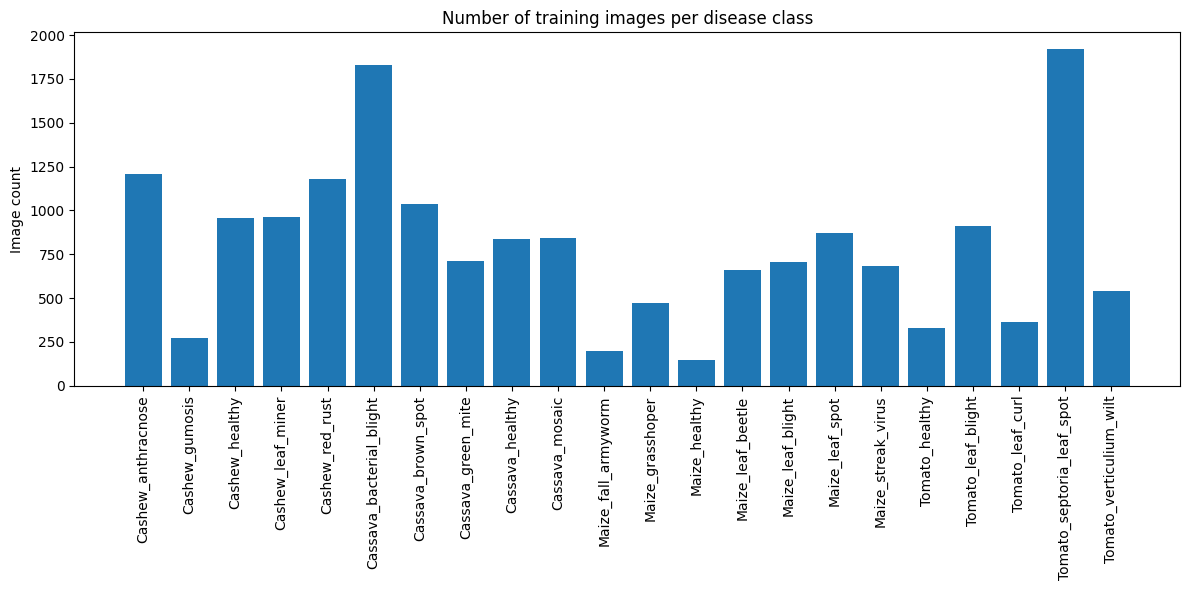

In [ ]:
# 1) Imports
import os
import pandas as pd
import matplotlib.pyplot as plt

# 2) Point to your train directory
train_dir = "/content/data/disease_data/train"

# 3) Gather class names and counts
classes = sorted(os.listdir(train_dir))
counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]

# 4) Create a DataFrame for easy viewing
df = pd.DataFrame({"disease": classes, "count": counts})
df

# 5) Plot the imbalance
plt.figure(figsize=(12,6))
plt.bar(df["disease"], df["count"])
plt.xticks(rotation=90)
plt.title("Number of training images per disease class")
plt.ylabel("Image count")
plt.tight_layout()
plt.show()

##2.2 Visualize random samples per class


In [ ]:
# --- Cell: Setup paths and imports ---
import os, random
from PIL import Image
import matplotlib.pyplot as plt

# Adjust this if your dataset lives elsewhere
TRAIN_DIR = "/content/data/disease_data/train"

# Grab the class names
classes = sorted(os.listdir(TRAIN_DIR))
print(f"Found classes: {classes}")

# Quick sanity check
assert all(os.path.isdir(os.path.join(TRAIN_DIR, c)) for c in classes), "One of the class folders is missing!"

Found classes: ['Cashew_anthracnose', 'Cashew_gumosis', 'Cashew_healthy', 'Cashew_leaf_miner', 'Cashew_red_rust', 'Cassava_bacterial_blight', 'Cassava_brown_spot', 'Cassava_green_mite', 'Cassava_healthy', 'Cassava_mosaic', 'Maize_fall_armyworm', 'Maize_grasshoper', 'Maize_healthy', 'Maize_leaf_beetle', 'Maize_leaf_blight', 'Maize_leaf_spot', 'Maize_streak_virus', 'Tomato_healthy', 'Tomato_leaf_blight', 'Tomato_leaf_curl', 'Tomato_septoria_leaf_spot', 'Tomato_verticulium_wilt']


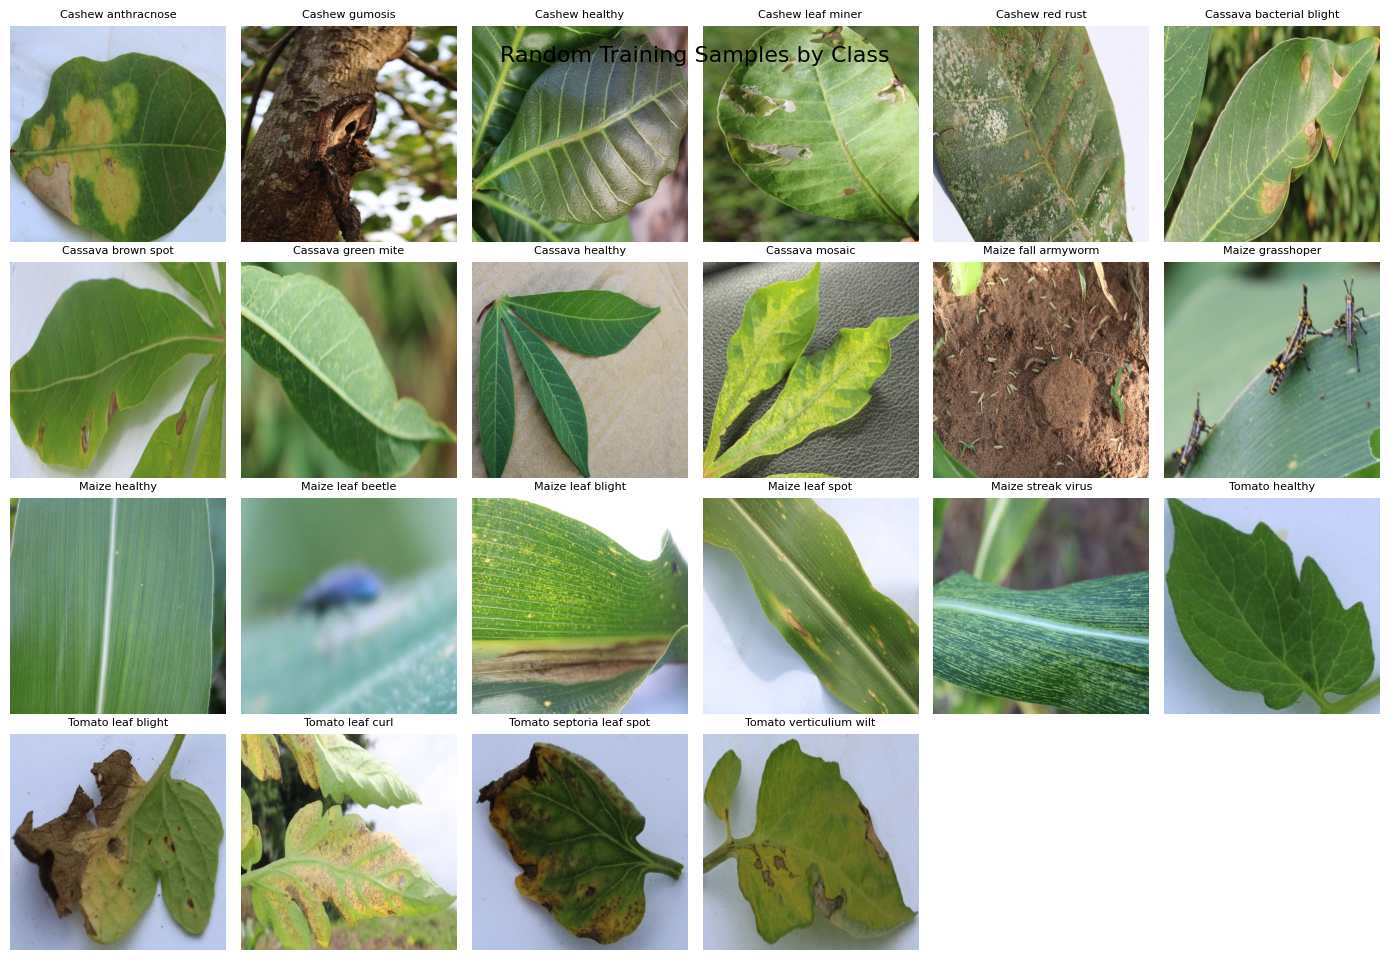

In [ ]:
# --- Cell: Random sample from each class ---
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(14, 10))
for i, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    # pick a random file (skip hidden files)
    fn = random.choice([f for f in os.listdir(cls_dir) if not f.startswith('.')])
    img = Image.open(os.path.join(cls_dir, fn)).convert("RGB")

    ax = plt.subplot(4, 6, i+1)       # 4 rows × 6 columns layout for 22 classes
    ax.imshow(img)
    ax.set_title(cls.replace('_', ' '), fontsize=8)
    ax.axis('off')

plt.suptitle("Random Training Samples by Class", fontsize=16, y=0.92)
plt.tight_layout()
plt.show()

## 2.3 Plot Image Size Distribution

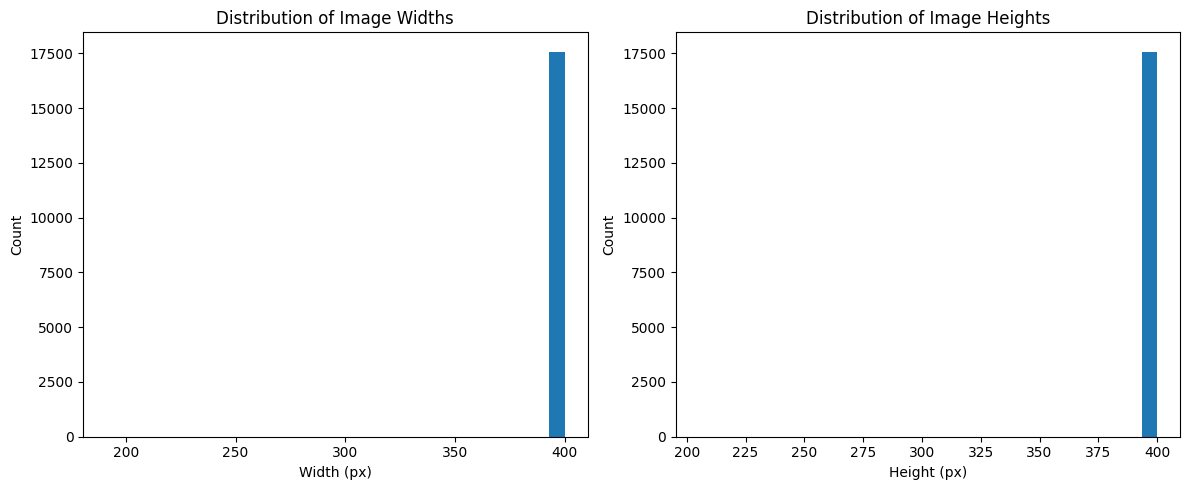

In [ ]:
# --- Cell: Image width & height histograms ---
widths, heights = [], []
for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir):
        path = os.path.join(cls_dir, fname)
        try:
            w, h = Image.open(path).size
            widths.append(w)
            heights.append(h)
        except:
            continue   # skip any unreadable file

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title("Distribution of Image Widths")
plt.xlabel("Width (px)")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title("Distribution of Image Heights")
plt.xlabel("Height (px)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 2.4: Compute & Visualize Class Imbalance, and prepare for weighted sampling.

Class         Count    Weight
Cashew_anthracnose      1210    0.437
Cashew_gumosis           274    1.932
Cashew_healthy           957    0.553
Cashew_leaf_miner        964    0.549
Cashew_red_rust         1177    0.450
Cassava_bacterial_blight  1829    0.289
Cassava_brown_spot      1036    0.511
Cassava_green_mite       710    0.746
Cassava_healthy          835    0.634
Cassava_mosaic           843    0.628
Maize_fall_armyworm      199    2.660
Maize_grasshoper         471    1.124
Maize_healthy            145    3.650
Maize_leaf_beetle        663    0.798
Maize_leaf_blight        704    0.752
Maize_leaf_spot          873    0.606
Maize_streak_virus       684    0.774
Tomato_healthy           329    1.609
Tomato_leaf_blight       910    0.582
Tomato_leaf_curl         362    1.462
Tomato_septoria_leaf_spot  1920    0.276
Tomato_verticulium_wilt   541    0.978


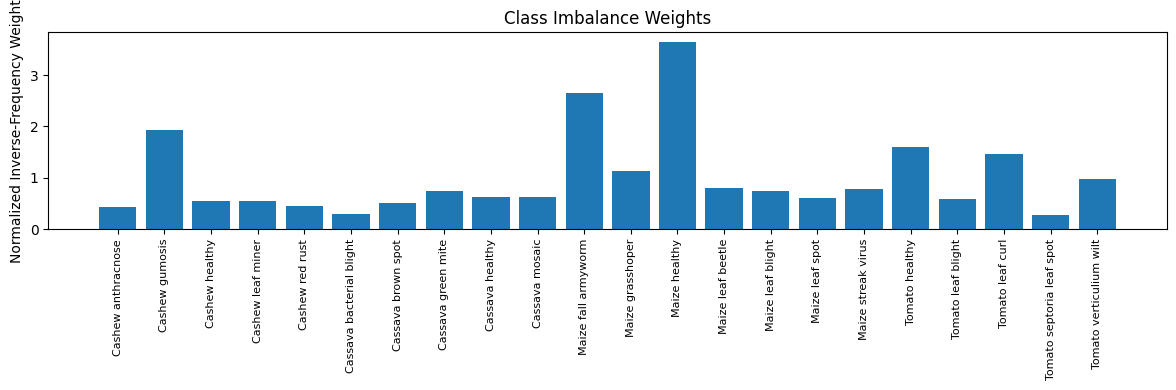

In [ ]:
import os
from collections import Counter
import matplotlib.pyplot as plt

# Path to your training directory
TRAIN_DIR = "/content/disease_data/train"

# 1. Count images per class
classes = sorted(os.listdir(TRAIN_DIR))
counts = Counter({cls: len(os.listdir(os.path.join(TRAIN_DIR, cls)))
                  for cls in classes})

total_images = sum(counts.values())

# 2. Compute frequencies and inverse frequencies
freqs = {cls: counts[cls] / total_images for cls in classes}
inv_freqs = {cls: 1.0 / freqs[cls] for cls in classes}

# 3. Normalize so mean weight = 1
mean_inv = sum(inv_freqs.values()) / len(inv_freqs)
class_weights = [inv_freqs[cls] / mean_inv for cls in classes]

# 4. Display
print("Class         Count    Weight")
for cls, cnt, w in zip(classes, counts.values(), class_weights):
    print(f"{cls:<22} {cnt:>5}    {w:.3f}")

# 5. Bar chart of weights
plt.figure(figsize=(12,4))
plt.bar(range(len(classes)), class_weights)
plt.xticks(range(len(classes)), [c.replace('_',' ') for c in classes],
           rotation=90, fontsize=8)
plt.ylabel("Normalized Inverse-Frequency Weight")
plt.title("Class Imbalance Weights")
plt.tight_layout()
plt.show()

#  Build WeightedRandomSampler & Dataloaders

We construct our PyTorch `ImageFolder` datasets, then apply the computed inverse-frequency weights to create a `WeightedRandomSampler` for the training loader. Validation and test loaders remain unweighted.

In [ ]:
import os
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms

# 1. Paths
DATA_DIR   = "/content/disease_data"
TRAIN_DIR  = os.path.join(DATA_DIR, "train")
VAL_DIR    = os.path.join(DATA_DIR, "val")
TEST_DIR   = os.path.join(DATA_DIR, "test")

# 2. Image transforms
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),       # ConvNeXt expects 224×224
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# 3. Build the raw training dataset
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

# 4. Prepare sample weights for each image in train_ds
#    Using the per-class normalized inverse-freq weights computed earlier:
class_weights_list = torch.tensor([
    0.437, 1.932, 0.553, 0.549, 0.450, 0.289, 0.511,
    0.746, 0.634, 0.628, 2.660, 1.124, 3.650, 0.798,
    0.752, 0.606, 0.774, 1.609, 0.582, 1.462, 0.276, 0.978
], dtype=torch.float)

# Map each sample to its class weight
sample_weights = [ class_weights_list[label] for _, label in train_ds.samples ]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# 5. Create DataLoaders
batch_size = 32

train_loader = DataLoader(
    train_ds, batch_size=batch_size,
    sampler=sampler, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=batch_size,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=batch_size,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"→ Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

→ Train batches: 552, Val batches: 118


# Clone Repo & Place Data

I clone my `crop_detection_thesis` repository, ensure its `src/` folder and scripts are present, then copy my unzipped `disease_data/` into the repo’s `data/` directory.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!git clone https://github.com/chaitanyahandore/crop_detection_thesis.git
%cd crop_detection_thesis

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'crop_detection_thesis'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 43 (delta 11), reused 24 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 21.11 KiB | 21.11 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/crop_detection_thesis


In [ ]:
%cd /content/crop_detection_thesis

!ls

/content/crop_detection_thesis
best_resnet50.pth  requirements.txt  src


In [ ]:
%cd /content/crop_detection_thesis

/content/crop_detection_thesis


# train_single_crop.py

## OLD MODELS (resnet50, vgg16, alexnet)

In [ ]:
%matplotlib inline

In [ ]:
!pip install torch torchvision timm --quiet

In [ ]:
from IPython.display import Image, display

###resnet50

In [ ]:
!python3 src/train_single_crop.py \
  --data_dir /content/data/disease_data \
  --crop Maize \
  --model resnet50 \
  --pretrained \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --class_weights 1.796 0.759 2.465 0.539 0.508 0.409 0.523

→ `Maize` has 7 subclasses: ['fall_armyworm', 'grasshoper', 'healthy', 'leaf_beetle', 'leaf_blight', 'leaf_spot', 'streak_virus']
→ Building `resnet50`, pretrained=True
Epoch 1/20  Train 1.2014/0.5761  Val   0.5935/0.7764
Epoch 2/20  Train 0.5767/0.7598  Val   0.4255/0.8367
Epoch 3/20  Train 0.4977/0.7874  Val   0.3875/0.8518
Epoch 4/20  Train 0.4316/0.8082  Val   0.4384/0.8103
Epoch 5/20  Train 0.4250/0.8069  Val   0.3829/0.8467
Epoch 6/20  Train 0.3834/0.8272  Val   0.3722/0.8467
Epoch 7/20  Train 0.3445/0.8403  Val   0.3774/0.8568
Epoch 8/20  Train 0.3585/0.8387  Val   0.3581/0.8606
Epoch 9/20  Train 0.3360/0.8451  Val   0.3593/0.8505
Epoch 10/20  Train 0.3157/0.8604  Val   0.3444/0.8643
Epoch 11/20  Train 0.3122/0.8484  Val   0.3455/0.8568
Epoch 12/20  Train 0.3215/0.8492  Val   0.3659/0.8618
Epoch 13/20  Train 0.2748/0.8698  Val   0.3439/0.8656
Epoch 14/20  Train 0.2852/0.8655  Val   0.3581/0.8681
Epoch 15/20  Train 0.2627/0.8738  Val   0.3462/0.8719
Epoch 16/20  Train 0.2594/0.87

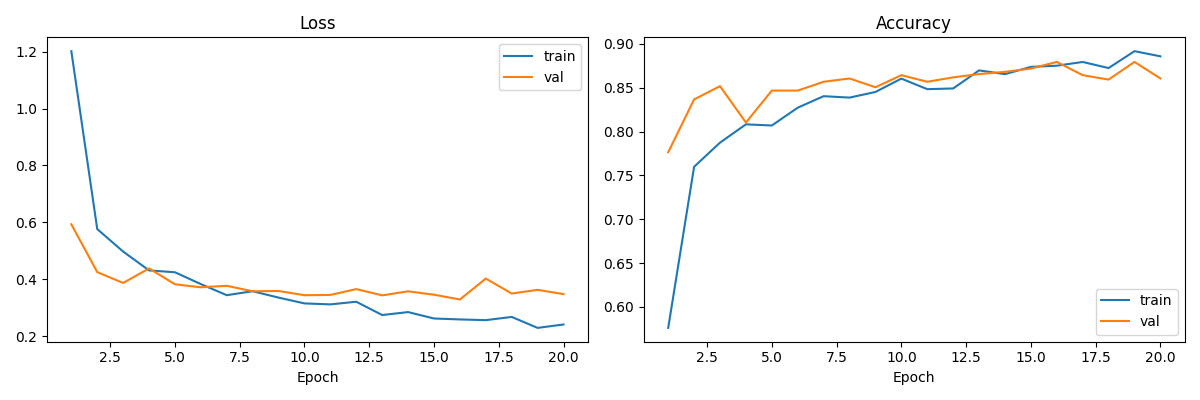

In [ ]:
display(Image("training_curves_resnet50.png"))

###vgg16

In [ ]:
!python src/train_single_crop.py \
  --data_dir /content/data/disease_data \
  --crop Maize \
  --model vgg16 \
  --pretrained \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --class_weights 1.796 0.759 2.465 0.539 0.508 0.409 0.523

→ `Maize` has 7 subclasses: ['fall_armyworm', 'grasshoper', 'healthy', 'leaf_beetle', 'leaf_blight', 'leaf_spot', 'streak_virus']
→ Building `vgg16`, pretrained=True
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100% 528M/528M [00:02<00:00, 205MB/s]
Epoch 1/20  Train 1.1829/0.5304  Val   0.7248/0.7374
Epoch 2/20  Train 0.7810/0.6785  Val   0.5369/0.8065
Epoch 3/20  Train 0.6821/0.7280  Val   0.5306/0.7977
Epoch 4/20  Train 0.6317/0.7382  Val   0.5298/0.7889
Epoch 5/20  Train 0.6347/0.7465  Val   0.4328/0.8379
Epoch 6/20  Train 0.5061/0.7807  Val   0.4553/0.8405
Epoch 7/20  Train 0.5337/0.7820  Val   0.4508/0.8342
Epoch 8/20  Train 0.5876/0.7679  Val   0.4244/0.8455
Epoch 9/20  Train 0.5024/0.7925  Val   0.4337/0.8367
Epoch 10/20  Train 0.4655/0.7946  Val   0.5602/0.8053
Epoch 11/20  Train 0.4931/0.7887  Val   0.4007/0.8392
Epoch 12/20  Train 0.4575/0.8109  Val   0.4107/0.8580
Epoch 13/20  Train 0.4107/0.81

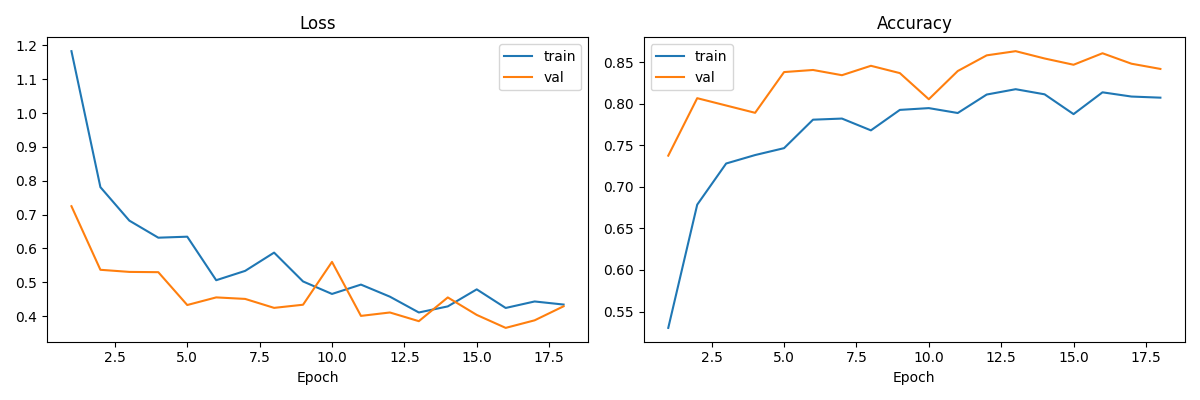

In [ ]:
display(Image("training_curves_vgg16.png"))

###alexnet

In [ ]:
!python src/train_single_crop.py \
  --data_dir /content/data/disease_data \
  --crop Maize \
  --model alexnet \
  --pretrained \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --class_weights 1.796 0.759 2.465 0.539 0.508 0.409 0.523

→ `Maize` has 7 subclasses: ['fall_armyworm', 'grasshoper', 'healthy', 'leaf_beetle', 'leaf_blight', 'leaf_spot', 'streak_virus']
→ Building `alexnet`, pretrained=True
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100% 233M/233M [00:01<00:00, 218MB/s]
Epoch 1/20  Train 1.1193/0.5606  Val   0.7809/0.6847
Epoch 2/20  Train 0.7604/0.6796  Val   0.6593/0.7462
Epoch 3/20  Train 0.7291/0.6922  Val   0.5805/0.7613
Epoch 4/20  Train 0.6547/0.7227  Val   0.5854/0.7676
Epoch 5/20  Train 0.6026/0.7360  Val   0.5215/0.7965
Epoch 6/20  Train 0.5645/0.7537  Val   0.5118/0.7877
Epoch 7/20  Train 0.5510/0.7601  Val   0.4677/0.8040
Epoch 8/20  Train 0.5376/0.7582  Val   0.5267/0.7915
Epoch 9/20  Train 0.5508/0.7638  Val   0.4990/0.8065
Epoch 10/20  Train 0.5139/0.7729  Val   0.4598/0.8254
Epoch 11/20  Train 0.5044/0.7892  Val   0.4817/0.8216
Epoch 12/20  Train 0.4732/0.7925  Val   0.4813/0.8128
Epoch 13/20  Tra

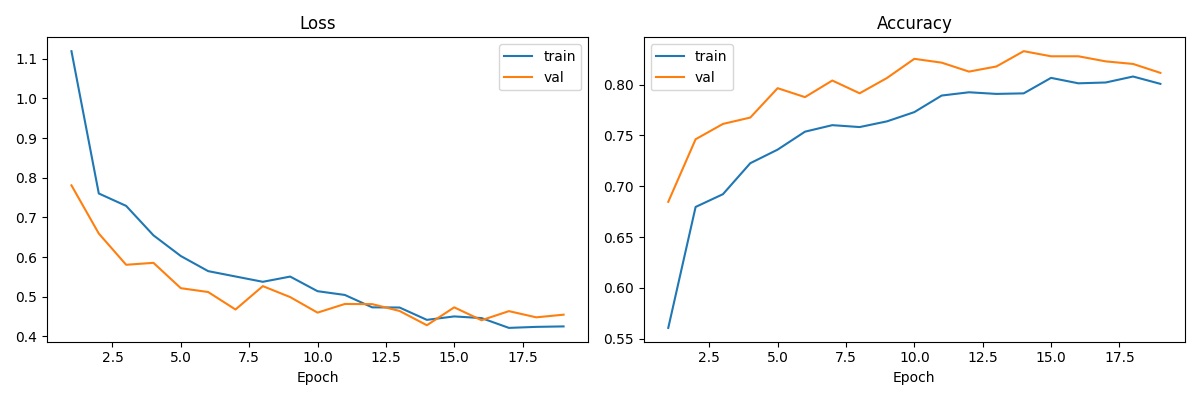

In [ ]:
display(Image("training_curves_alexnet.png"))

## NEW MODELS (convnext_tiny, vit_b_16, mobilevit_s)

###convnext_tiny

In [ ]:
!python src/train_single_crop.py \
  --data_dir /content/data/disease_data \
  --crop Maize \
  --model convnext_tiny \
  --pretrained \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --class_weights 1.796 0.759 2.465 0.539 0.508 0.409 0.523

→ `Maize` has 7 subclasses: ['fall_armyworm', 'grasshoper', 'healthy', 'leaf_beetle', 'leaf_blight', 'leaf_spot', 'streak_virus']
→ Building `convnext_tiny`, pretrained=True
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100% 109M/109M [00:00<00:00, 207MB/s] 
Epoch 1/20  Train 0.8410/0.6732  Val   0.4764/0.8229
Epoch 2/20  Train 0.4713/0.7962  Val   0.3705/0.8593
Epoch 3/20  Train 0.3878/0.8197  Val   0.3764/0.8492
Epoch 4/20  Train 0.3856/0.8208  Val   0.3483/0.8631
Epoch 5/20  Train 0.3407/0.8385  Val   0.3399/0.8631
Epoch 6/20  Train 0.3301/0.8462  Val   0.3541/0.8593
Epoch 7/20  Train 0.3076/0.8502  Val   0.3664/0.8593
Epoch 8/20  Train 0.2980/0.8561  Val   0.3533/0.8631
Epoch 9/20  Train 0.2665/0.8668  Val   0.3487/0.8719
Epoch 10/20  Train 0.2778/0.8671  Val   0.3307/0.8731
Epoch 11/20  Train 0.2559/0.8802  Val   0.3552/0.8681
Epoch 12/20  Train 0.2672/0.8799  Val   0.3452/0.8656
Epoch

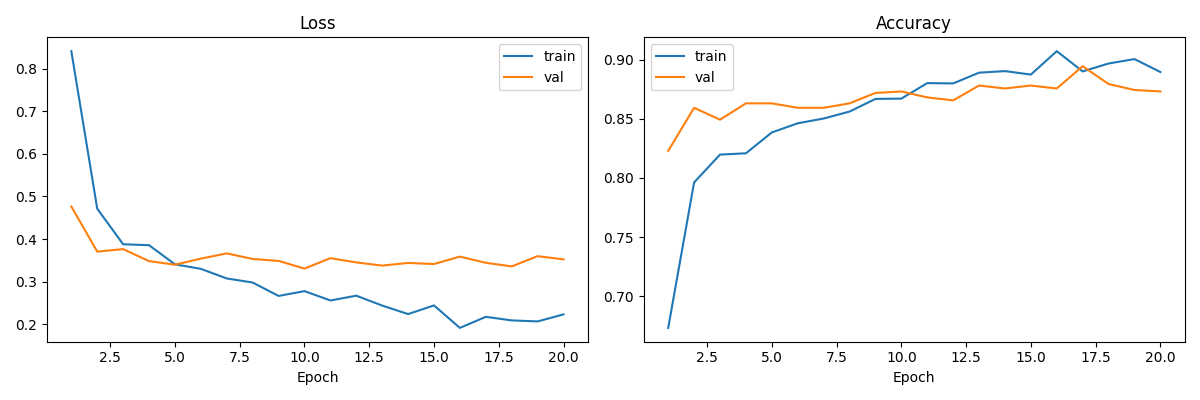

In [ ]:
display(Image("training_curves_convnext_tiny.png"))

###vit_b_16

In [ ]:
!python src/train_single_crop.py \
  --data_dir /content/data/disease_data \
  --crop Maize \
  --model vit_b_16 \
  --pretrained \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --class_weights 1.796 0.759 2.465 0.539 0.508 0.409 0.523

→ `Maize` has 7 subclasses: ['fall_armyworm', 'grasshoper', 'healthy', 'leaf_beetle', 'leaf_blight', 'leaf_spot', 'streak_virus']
→ Building `vit_b_16`, pretrained=True
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100% 330M/330M [00:01<00:00, 223MB/s]
Epoch 1/20  Train 0.7913/0.6860  Val   0.4208/0.8405
Epoch 2/20  Train 0.5238/0.7764  Val   0.4770/0.8329
Epoch 3/20  Train 0.4450/0.8005  Val   0.3788/0.8455
Epoch 4/20  Train 0.4492/0.8058  Val   0.3722/0.8518
Epoch 5/20  Train 0.4182/0.8149  Val   0.3830/0.8530
Epoch 6/20  Train 0.3579/0.8310  Val   0.3682/0.8480
Epoch 7/20  Train 0.3595/0.8262  Val   0.3514/0.8555
Epoch 8/20  Train 0.3573/0.8318  Val   0.4004/0.8342
Epoch 9/20  Train 0.3826/0.8344  Val   0.4111/0.8354
Epoch 10/20  Train 0.3426/0.8414  Val   0.3660/0.8580
Epoch 11/20  Train 0.3134/0.8500  Val   0.3462/0.8744
Epoch 12/20  Train 0.3142/0.8532  Val   0.3201/0.8681
Epoch 13/20  Train 0.

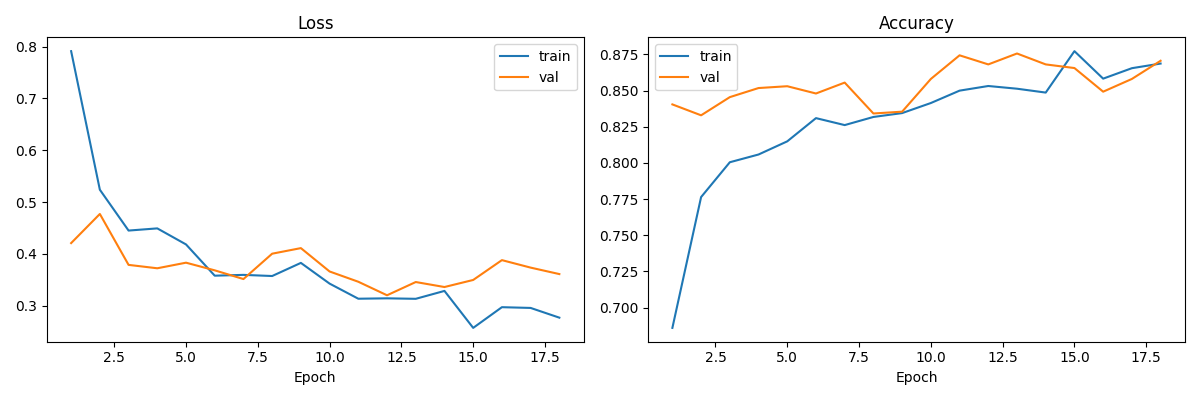

In [ ]:
display(Image("training_curves_vit_b_16.png"))

###mobilevit_s

In [ ]:
!python src/train_single_crop.py \
  --data_dir /content/data/disease_data \
  --crop Maize \
  --model mobilevit_s \
  --pretrained \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --class_weights 1.796 0.759 2.465 0.539 0.508 0.409 0.523

→ `Maize` has 7 subclasses: ['fall_armyworm', 'grasshoper', 'healthy', 'leaf_beetle', 'leaf_blight', 'leaf_spot', 'streak_virus']
→ Building `mobilevit_s`, pretrained=True
model.safetensors: 100% 22.4M/22.4M [00:00<00:00, 122MB/s] 
Epoch 1/20  Train 1.6011/0.4533  Val   1.2007/0.7123
Epoch 2/20  Train 0.8882/0.7042  Val   0.7122/0.7864
Epoch 3/20  Train 0.6573/0.7539  Val   0.5756/0.8040
Epoch 4/20  Train 0.5778/0.7761  Val   0.4975/0.8166
Epoch 5/20  Train 0.5209/0.7927  Val   0.4752/0.8241
Epoch 6/20  Train 0.4844/0.8018  Val   0.4480/0.8405
Epoch 7/20  Train 0.4351/0.8200  Val   0.4274/0.8505
Epoch 8/20  Train 0.4313/0.8163  Val   0.4097/0.8530
Epoch 9/20  Train 0.4062/0.8302  Val   0.3837/0.8530
Epoch 10/20  Train 0.4014/0.8224  Val   0.3793/0.8555
Epoch 11/20  Train 0.3831/0.8315  Val   0.3951/0.8505
Epoch 12/20  Train 0.3690/0.8465  Val   0.3589/0.8668
Epoch 13/20  Train 0.3560/0.8422  Val   0.3776/0.8593
Epoch 14/20  Train 0.3318/0.8558  Val   0.3579/0.8656
Epoch 15/20  Train 0.

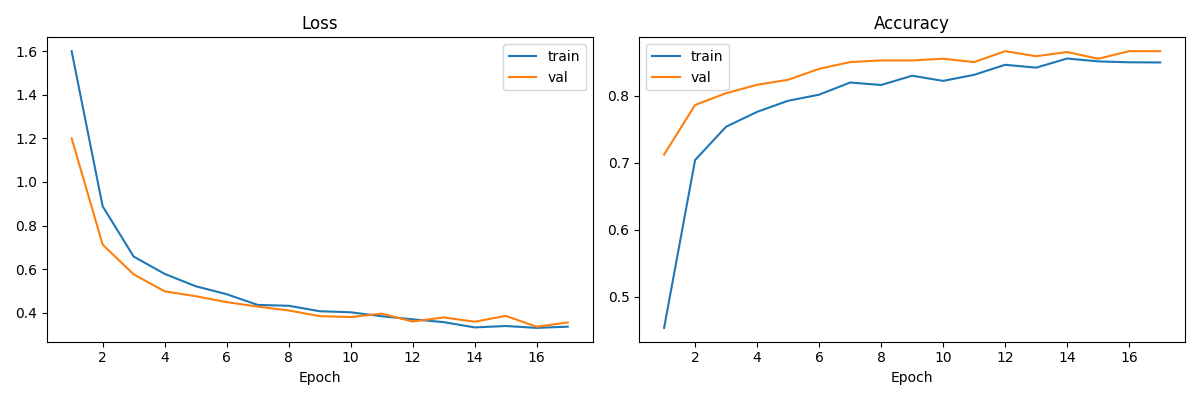

In [ ]:
display(Image("training_curves_mobilevit_s.png"))

## Evaluation

In [ ]:
# move into your repo root
%cd /content/crop_detection_thesis

/content/crop_detection_thesis


In [ ]:
%%bash
cat > eval_all_models.py << 'EOF'
#!/usr/bin/env python3
import torch, numpy as np, timm
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import transforms, models
from torch.utils.data import DataLoader
from train_single_crop import SingleCropDataset
import seaborn as sns, matplotlib.pyplot as plt, torch.nn as nn

# 1) Test‐time transforms
test_tf = transforms.Compose([
  transforms.Resize(256), transforms.CenterCrop(224),
  transforms.ToTensor(),
  transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# 2) DataLoader
DATA_DIR = "data/disease_data"
CROP     = "Maize"
test_ds  = SingleCropDataset(DATA_DIR, CROP, "test", transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
classes = test_ds.idx_to_class
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# helper to evaluate any model
def eval_model(name, build_fn, ckpt):
    print(f"\n=== {name} ===")
    model = build_fn().to(device).eval()
    model.load_state_dict(torch.load(ckpt, map_location="cpu"))
    all_p, all_t = [], []
    with torch.no_grad():
      for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_p.append(preds); all_t.append(labels.numpy())
    y_pred = np.concatenate(all_p); y_true = np.concatenate(all_t)
    print(f"Acc: {(y_pred==y_true).mean():.4f}")
    print(classification_report(y_true, y_pred, target_names=classes, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion – {name}")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"confusion_{name}.png")
    plt.show()

# 3) build functions + checkpoints for each model:
eval_model(
  "ConvNeXt-Tiny",
  lambda: (lambda m=models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT):
           (setattr(m.classifier[2], 'in_features', m.classifier[2].in_features) or m)
           or setattr(m.classifier[2], 'out_features', len(classes)) or m
          )(),
  "best_convnext_tiny.pth"
)
# repeat for Vit, MobileViT, ResNet50, VGG16, AlexNet…
# e.g.:
eval_model(
  "ResNet-50",
  lambda: (lambda m=models.resnet50(weights=models.ResNet50_Weights.DEFAULT):
           setattr(m.fc, 'out_features', len(classes)) or m)(),
  "best_resnet50.pth"
)
# …and so on for your six models
EOF

# confirm file is there
ls

best_alexnet.pth
best_convnext_tiny.pth
best_mobilevit_s.pth
best_resnet50.pth
best_vgg16.pth
best_vit_b_16.pth
eval_all_models.py
requirements.txt
src
training_curves_alexnet.png
training_curves_convnext_tiny.png
training_curves_mobilevit_s.png
training_curves_resnet50.png
training_curves_vgg16.png
training_curves_vit_b_16.png


In [ ]:
%cd /content/crop_detection_thesis
!python3 -m src.eval_all_models

/content/crop_detection_thesis
→ Loaded test set: 809 images, 7 classes


=== Evaluating alexnet ===
Accuracy: 0.8158

               precision    recall  f1-score   support

fall_armyworm     0.9000    0.8182    0.8571        44
   grasshoper     0.8938    0.9902    0.9395       102
      healthy     0.7045    0.9688    0.8158        32
  leaf_beetle     0.9848    0.9091    0.9455       143
  leaf_blight     0.6608    0.7434    0.6997       152
    leaf_spot     0.7321    0.6508    0.6891       189
 streak_virus     0.8936    0.8571    0.8750       147

     accuracy                         0.8158       809
    macro avg     0.8243    0.8482    0.8317       809
 weighted avg     0.8212    0.8158    0.8159       809

→ saved confusion matrix to cm_alexnet.png


=== Evaluating convnext_tiny ===
Accuracy: 0.8640

               precision    recall  f1-score   support

fall_armyworm     0.9756    0.9091    0.9412        44
   grasshoper     0.9804    0.9804    0.9804       102
      healt

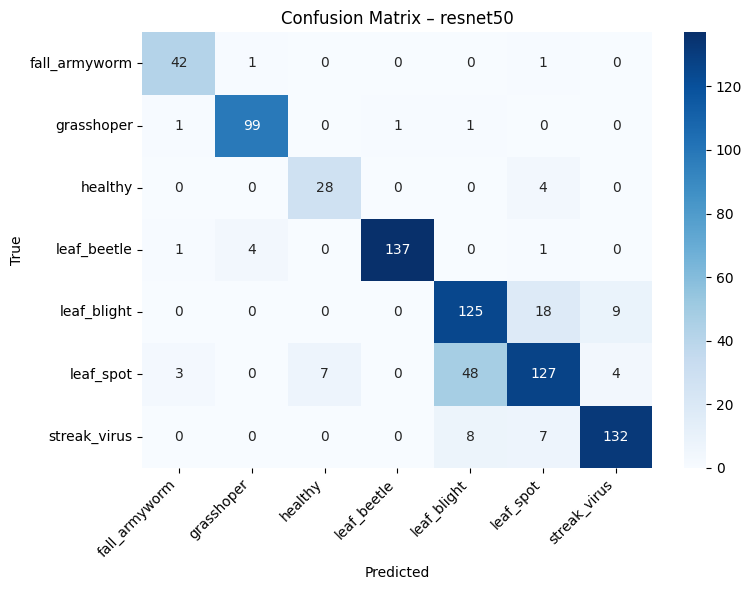

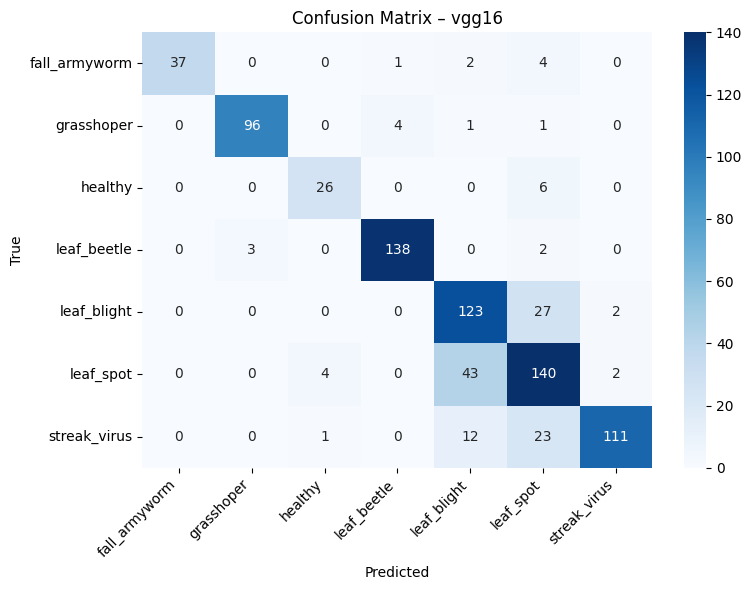

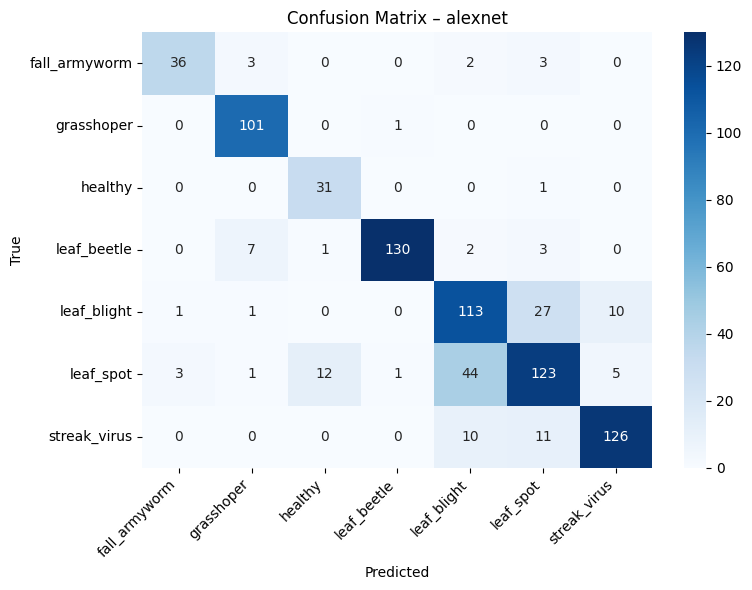

In [ ]:
# Old models
display(Image("cm_resnet50.png"))
display(Image("cm_vgg16.png"))
display(Image("cm_alexnet.png"))

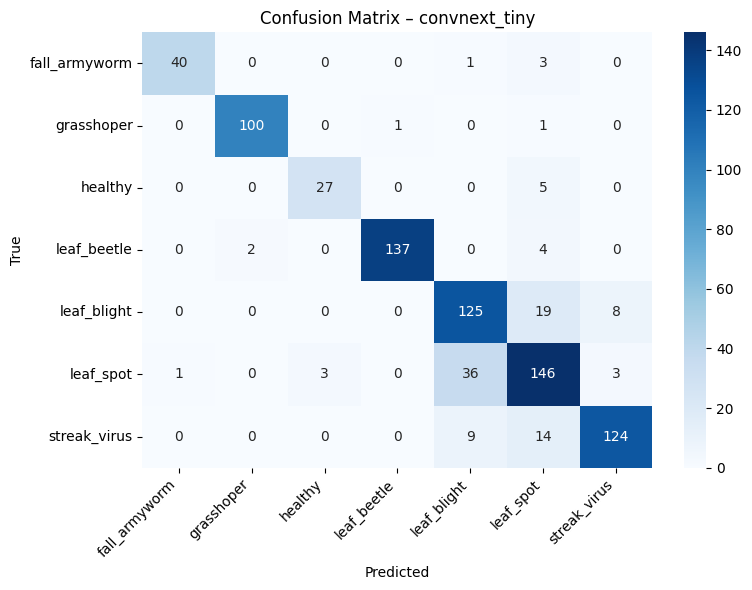

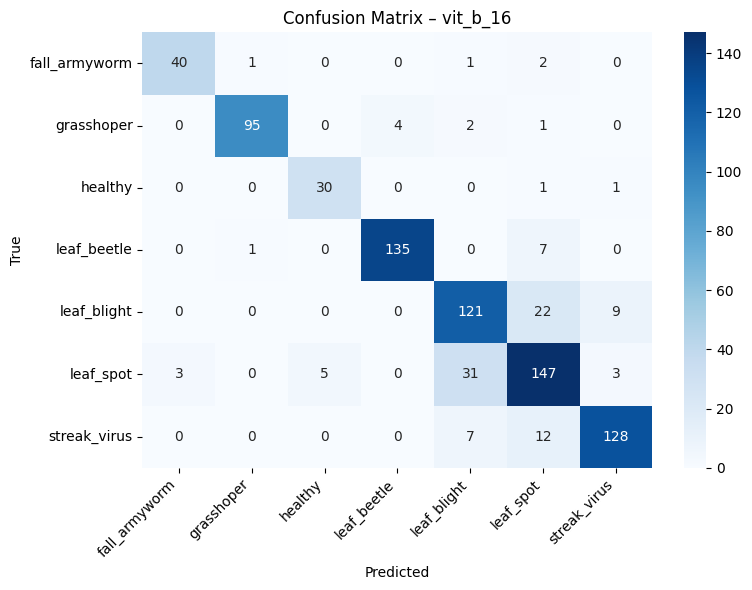

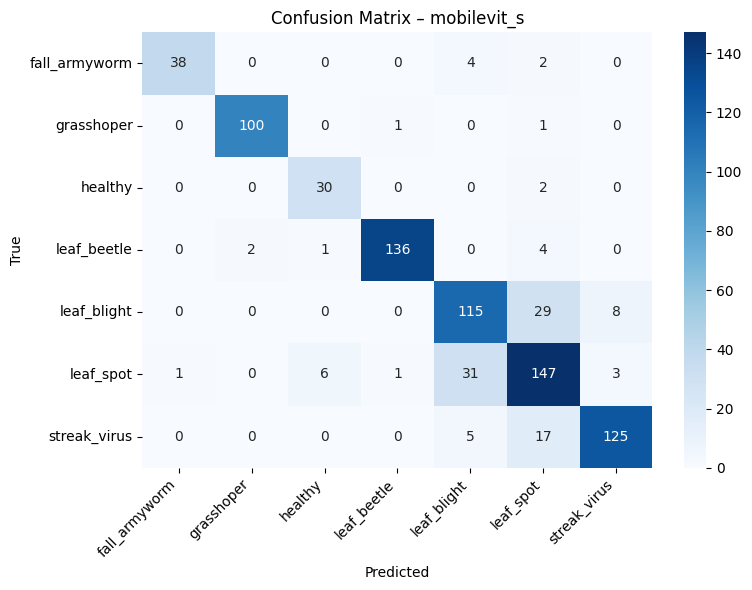

In [ ]:
# New models
display(Image("cm_convnext_tiny.png"))
display(Image("cm_vit_b_16.png"))
display(Image("cm_mobilevit_s.png"))

# train_all_crop.py

In [ ]:
%%bash
# Create a cleaning script
mkdir -p scripts

cat > scripts/clean_dataset.py << 'EOF'
#!/usr/bin/env python3
import os
from PIL import Image, UnidentifiedImageError

# Point this at your unzipped data folder
DATA_ROOT = os.path.join(os.path.dirname(__file__), '..', 'data', 'disease_data')

def clean(split_folder):
    removed = 0
    for subdir, _, files in os.walk(split_folder):
        for f in files:
            path = os.path.join(subdir, f)
            try:
                # try opening & verifying the image
                with Image.open(path) as img:
                    img.verify()
            except (UnidentifiedImageError, OSError):
                echo_path = path.replace(DATA_ROOT, '...')
                print(f"→ Removing corrupt image: {echo_path}")
                os.remove(path)
                removed += 1
    print(f"Cleaned {os.path.basename(split_folder)}: removed {removed} files.")

if __name__ == "__main__":
    for split in ("train","val","test"):
        folder = os.path.join(DATA_ROOT, split)
        print(f"\nCleaning split: {split}")
        clean(folder)
    print("\nAll done!")
EOF

# Make it executable
chmod +x scripts/clean_dataset.py

# Install pillow if needed
pip install --quiet pillow

# Run the cleaner
python3 scripts/clean_dataset.py


Cleaning split: train
Cleaned train: removed 0 files.

Cleaning split: val
Cleaned val: removed 0 files.

Cleaning split: test
Cleaned test: removed 0 files.

All done!


## OLD MODELS (resnet50, vgg16, alexnet)

###ResNet-50

In [ ]:
# ResNet-50
!python3 src/train_all_crops.py \
  --data_dir /content/data/disease_data \
  --model resnet50 \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --pretrained

→ Classes (22): ['Cashew_anthracnose', 'Cashew_gumosis', 'Cashew_healthy', 'Cashew_leaf_miner', 'Cashew_red_rust', 'Cassava_bacterial_blight', 'Cassava_brown_spot', 'Cassava_green_mite', 'Cassava_healthy', 'Cassava_mosaic', 'Maize_fall_armyworm', 'Maize_grasshoper', 'Maize_healthy', 'Maize_leaf_beetle', 'Maize_leaf_blight', 'Maize_leaf_spot', 'Maize_streak_virus', 'Tomato_healthy', 'Tomato_leaf_blight', 'Tomato_leaf_curl', 'Tomato_septoria_leaf_spot', 'Tomato_verticulium_wilt']
Epoch 1/20  Train 1.0197/0.5799  Val   0.7627/0.7176
Epoch 2/20  Train 0.4859/0.7630  Val   0.5814/0.7670
Epoch 3/20  Train 0.3906/0.7963  Val   0.5294/0.8004
Epoch 4/20  Train 0.3643/0.8115  Val   0.5022/0.8185
Epoch 5/20  Train 0.3369/0.8279  Val   0.4909/0.8264
Epoch 6/20  Train 0.3159/0.8331  Val   0.4543/0.8336
Epoch 7/20  Train 0.3106/0.8399  Val   0.4152/0.8426
Epoch 8/20  Train 0.2850/0.8514  Val   0.4066/0.8538
Epoch 9/20  Train 0.2745/0.8561  Val   0.3874/0.8631
Epoch 10/20  Train 0.2603/0.8623  Val   

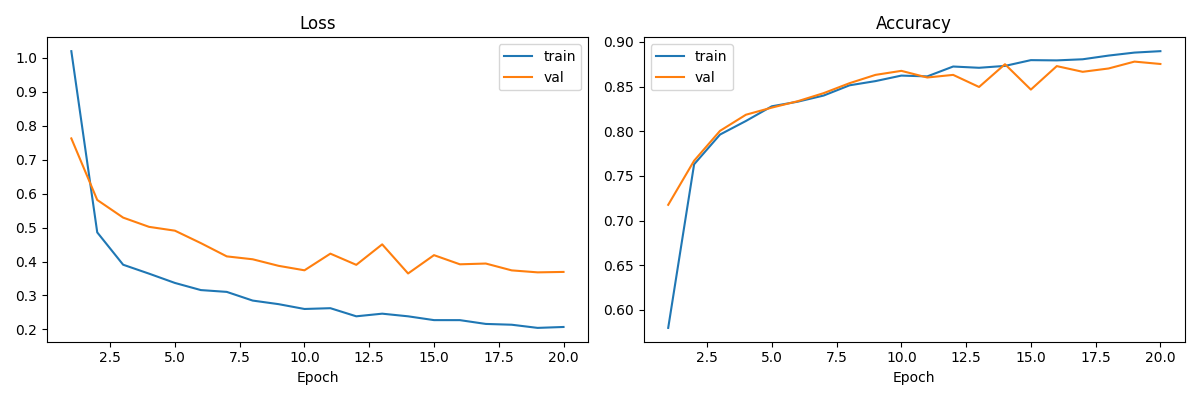

In [ ]:
display(Image("resnet50_loss_acc.png"))

### vgg16

In [ ]:
# vgg16
!python3 src/train_all_crops.py \
  --data_dir /content/data/disease_data \
  --model vgg16 \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --pretrained

→ Classes (22): ['Cashew_anthracnose', 'Cashew_gumosis', 'Cashew_healthy', 'Cashew_leaf_miner', 'Cashew_red_rust', 'Cassava_bacterial_blight', 'Cassava_brown_spot', 'Cassava_green_mite', 'Cassava_healthy', 'Cassava_mosaic', 'Maize_fall_armyworm', 'Maize_grasshoper', 'Maize_healthy', 'Maize_leaf_beetle', 'Maize_leaf_blight', 'Maize_leaf_spot', 'Maize_streak_virus', 'Tomato_healthy', 'Tomato_leaf_blight', 'Tomato_leaf_curl', 'Tomato_septoria_leaf_spot', 'Tomato_verticulium_wilt']
Epoch 1/20  Train 1.2466/0.4968  Val   0.9468/0.6444
Epoch 2/20  Train 0.7161/0.6672  Val   0.8585/0.6765
Epoch 3/20  Train 0.6646/0.6923  Val   0.8533/0.6738
Epoch 4/20  Train 0.5781/0.7160  Val   0.6811/0.7327
Epoch 5/20  Train 0.5291/0.7401  Val   0.7419/0.7142
Epoch 6/20  Train 0.5038/0.7493  Val   0.7099/0.7325
Epoch 7/20  Train 0.4870/0.7549  Val   0.6236/0.7402
Epoch 8/20  Train 0.4864/0.7590  Val   0.6081/0.7556
Epoch 9/20  Train 0.4503/0.7737  Val   0.6433/0.7545
Epoch 10/20  Train 0.4510/0.7767  Val   

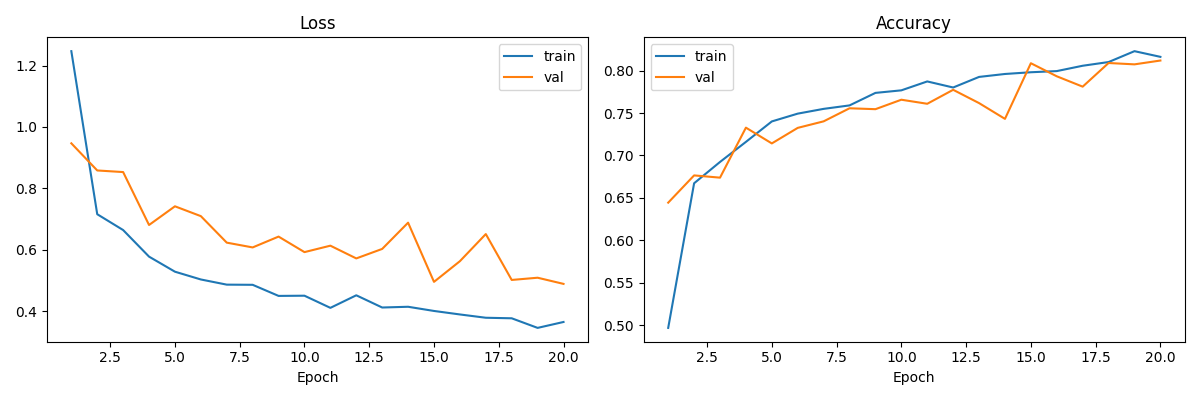

In [ ]:
display(Image("vgg16_loss_acc.png"))

###alexnet

In [ ]:
# alexnet
!python3 src/train_all_crops.py \
  --data_dir /content/data/disease_data \
  --model alexnet \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --pretrained

→ Classes (22): ['Cashew_anthracnose', 'Cashew_gumosis', 'Cashew_healthy', 'Cashew_leaf_miner', 'Cashew_red_rust', 'Cassava_bacterial_blight', 'Cassava_brown_spot', 'Cassava_green_mite', 'Cassava_healthy', 'Cassava_mosaic', 'Maize_fall_armyworm', 'Maize_grasshoper', 'Maize_healthy', 'Maize_leaf_beetle', 'Maize_leaf_blight', 'Maize_leaf_spot', 'Maize_streak_virus', 'Tomato_healthy', 'Tomato_leaf_blight', 'Tomato_leaf_curl', 'Tomato_septoria_leaf_spot', 'Tomato_verticulium_wilt']
Epoch 1/20  Train 1.2171/0.5074  Val   1.0029/0.6237
Epoch 2/20  Train 0.8251/0.6221  Val   1.0675/0.6409
Epoch 3/20  Train 0.7482/0.6543  Val   0.8785/0.6738
Epoch 4/20  Train 0.6628/0.6863  Val   0.7648/0.6998
Epoch 5/20  Train 0.6171/0.7035  Val   0.9290/0.6866
Epoch 6/20  Train 0.5910/0.7120  Val   0.7882/0.7131
Epoch 7/20  Train 0.5768/0.7203  Val   0.7615/0.7163
Epoch 8/20  Train 0.5610/0.7225  Val   0.7114/0.7240
Epoch 9/20  Train 0.5327/0.7332  Val   0.7396/0.7301
Epoch 10/20  Train 0.5210/0.7372  Val   

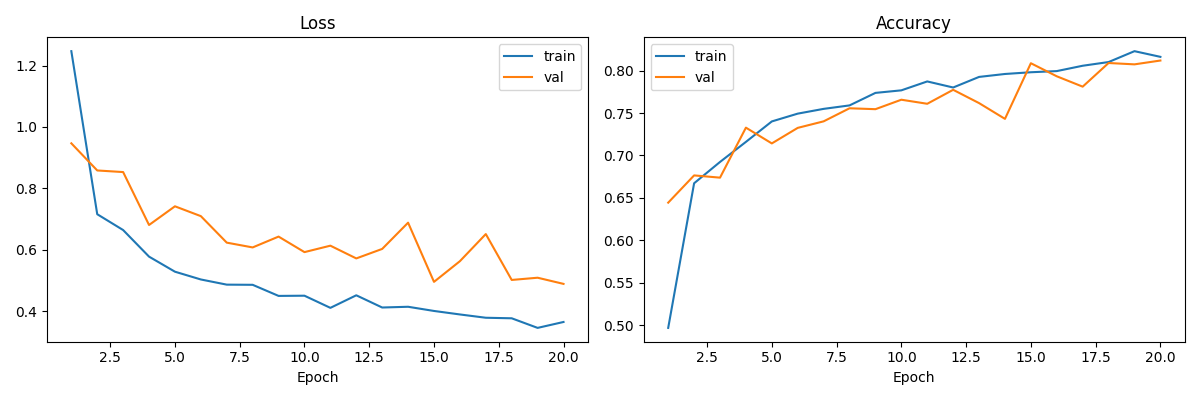

In [ ]:
display(Image("vgg16_loss_acc.png"))

## NEW MODELS (convnext_tiny, vit_b_16, mobilevit_s)

###convnext_tiny

In [ ]:
# convnext_tiny
!python3 src/train_all_crops.py \
  --data_dir /content/data/disease_data \
  --model convnext_tiny \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --pretrained

→ Classes (22): ['Cashew_anthracnose', 'Cashew_gumosis', 'Cashew_healthy', 'Cashew_leaf_miner', 'Cashew_red_rust', 'Cassava_bacterial_blight', 'Cassava_brown_spot', 'Cassava_green_mite', 'Cassava_healthy', 'Cassava_mosaic', 'Maize_fall_armyworm', 'Maize_grasshoper', 'Maize_healthy', 'Maize_leaf_beetle', 'Maize_leaf_blight', 'Maize_leaf_spot', 'Maize_streak_virus', 'Tomato_healthy', 'Tomato_leaf_blight', 'Tomato_leaf_curl', 'Tomato_septoria_leaf_spot', 'Tomato_verticulium_wilt']
Epoch 1/20  Train 0.7677/0.6688  Val   0.6012/0.7556
Epoch 2/20  Train 0.3976/0.8004  Val   0.5360/0.7895
Epoch 3/20  Train 0.3383/0.8242  Val   0.4756/0.8248
Epoch 4/20  Train 0.3065/0.8389  Val   0.3938/0.8511
Epoch 5/20  Train 0.2860/0.8469  Val   0.4102/0.8439
Epoch 6/20  Train 0.2646/0.8564  Val   0.3557/0.8657
Epoch 7/20  Train 0.2542/0.8655  Val   0.3228/0.8774
Epoch 8/20  Train 0.2295/0.8768  Val   0.3277/0.8763
Epoch 9/20  Train 0.2213/0.8817  Val   0.3318/0.8723
Epoch 10/20  Train 0.2215/0.8835  Val   

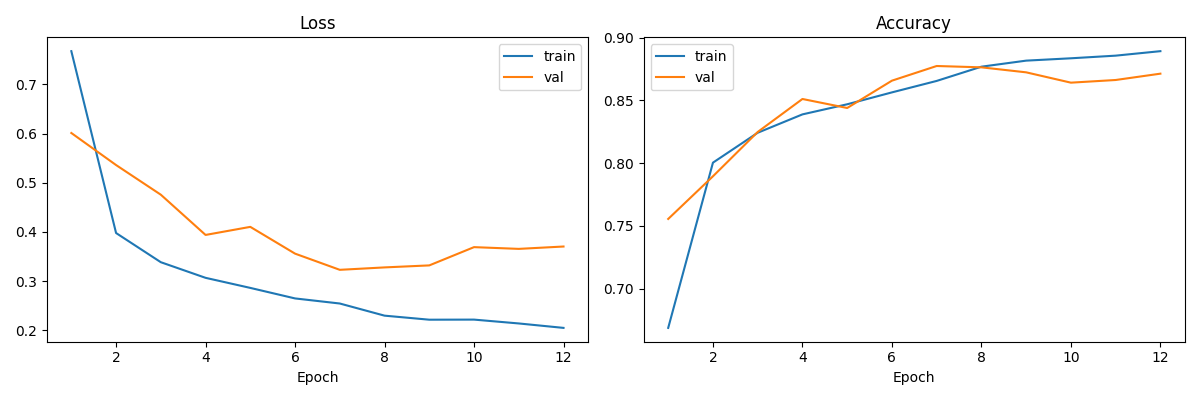

In [ ]:
display(Image("convnext_tiny_loss_acc.png"))

###vit_b_16

In [ ]:
# vit_b_16
!python3 src/train_all_crops.py \
  --data_dir /content/data/disease_data \
  --model vit_b_16 \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --pretrained

→ Classes (22): ['Cashew_anthracnose', 'Cashew_gumosis', 'Cashew_healthy', 'Cashew_leaf_miner', 'Cashew_red_rust', 'Cassava_bacterial_blight', 'Cassava_brown_spot', 'Cassava_green_mite', 'Cassava_healthy', 'Cassava_mosaic', 'Maize_fall_armyworm', 'Maize_grasshoper', 'Maize_healthy', 'Maize_leaf_beetle', 'Maize_leaf_blight', 'Maize_leaf_spot', 'Maize_streak_virus', 'Tomato_healthy', 'Tomato_leaf_blight', 'Tomato_leaf_curl', 'Tomato_septoria_leaf_spot', 'Tomato_verticulium_wilt']
Epoch 1/20  Train 0.7289/0.6786  Val   0.6411/0.7487
Epoch 2/20  Train 0.4497/0.7801  Val   0.6786/0.7463
Epoch 3/20  Train 0.4187/0.7916  Val   0.5791/0.7837
Epoch 4/20  Train 0.3647/0.8121  Val   0.6194/0.7699
Epoch 5/20  Train 0.3646/0.8137  Val   0.4849/0.8140
Epoch 6/20  Train 0.3328/0.8271  Val   0.4698/0.8262
Epoch 7/20  Train 0.3186/0.8361  Val   0.4814/0.8145
Epoch 8/20  Train 0.3075/0.8378  Val   0.4323/0.8355
Epoch 9/20  Train 0.2969/0.8462  Val   0.4581/0.8315
Epoch 10/20  Train 0.3110/0.8415  Val   

In [ ]:
display(Image("vit_b_16_loss_acc.png"))

###mobilevit_s

In [ ]:
# mobilevit_s
!python3 src/train_all_crops.py \
  --data_dir /content/data/disease_data \
  --model mobilevit_s \
  --epochs 20 \
  --batch_size 32 \
  --lr 1e-4 \
  --weight_decay 1e-2 \
  --pretrained

In [ ]:
display(Image("mobilevit_s_loss_acc.png"))